# Week 2 Artifact - Analytical SQL Patterns with NYC Taxi Data

## Overview

This notebook builds on the Week 1 DuckDB ingestion workflow and focuses on analytical SQL patterns using the NYC Yellow Taxi dataset.

The goal is to move beyond basic querying and use SQL to identify real patterns in trip demand, fare behavior, and operational activity.

This notebook explores:

- time-based demand patterns
- fare and distance trends
- passenger count distributions
- window functions for ranking and cumulative analysis
- practical analytical questions using a large local dataset

## Objective

The purpose of this notebook is to practice analytical SQL patterns on a large real-world dataset using DuckDB.

Specifically, this analysis aims to:

1. Reconnect to the local DuckDB database created in Week 1
2. Validate the dataset and schema
3. Explore trip activity across time
4. Analyze fare and trip-distance behavior
5. Apply window functions for ranking and cumulative metrics
6. Extract business-style insights from the data

This serves as the second artifact in a broader research curriculum focused on modern data systems and applied analytics.

## Dataset

Dataset: NYC Yellow Taxi Trip Data

This analysis uses a combined dataset built from the following source files:

- yellow_tripdata_2015-01.csv
- yellow_tripdata_2016-01.csv
- yellow_tripdata_2016-02.csv
- yellow_tripdata_2016-03.csv

The underlying DuckDB database was created in Week 1 and includes a cleaned analytical view for downstream analysis.

Relevant fields include:

- pickup and dropoff timestamps
- passenger_count
- trip_distance
- fare_amount
- tip_amount
- total_amount
- pickup/dropoff location identifiers

## Analysis Plan

This notebook is organized into the following sections:

1. Connect to the DuckDB database
2. Validate table structure and row counts
3. Explore trip demand by hour, day, and month
4. Analyze fare and distance patterns
5. Apply analytical SQL patterns such as ranking and cumulative totals
6. Summarize findings and key insights

In [17]:
con = duckdb.connect("../data/taxi.duckdb")

con.execute("""
CREATE TABLE taxi_trips AS
SELECT *
FROM read_csv_auto('../data/nyc_taxi/*.csv', union_by_name=True)
""")

FloatProgress(value=0.0, layout=Layout(width='auto'), style=ProgressStyle(bar_color='black'))

## Step 1 - Connect to the DuckDB Database

The analysis begins by connecting to the local DuckDB database created in Week 1.

This allows the notebook to reuse the previously materialized taxi dataset without reloading raw CSV files.

In [18]:
import duckdb
import pandas as pd
import matplotlib.pyplot as plt

con = duckdb.connect("../data/taxi.duckdb")

## Step 2 - Validate the Data

Before beginning analysis, it is useful to confirm:

- the available tables and views
- the total number of rows
- the inferred schema

This acts as a quick sanity check before deeper exploration.

In [19]:
con.execute("SHOW TABLES").df()

,name
0,taxi_trips


In [20]:
con.execute("""
SELECT COUNT(*) AS total_rows
FROM taxi_trips
""").df()

,total_rows
0,47248845


In [21]:
con.execute("DESCRIBE taxi_trips").df()

,column_name,column_type,null,key,default,extra
0,VendorID,BIGINT,YES,None,None,None
1,tpep_pickup_datetime,TIMESTAMP,YES,None,None,None
2,tpep_dropoff_datetime,TIMESTAMP,YES,None,None,None
3,passenger_count,BIGINT,YES,None,None,None
4,trip_distance,DOUBLE,YES,None,None,None
5,pickup_longitude,DOUBLE,YES,None,None,None
6,pickup_latitude,DOUBLE,YES,None,None,None
7,RateCodeID,BIGINT,YES,None,None,None
8,store_and_fwd_flag,VARCHAR,YES,None,None,None
9,dropoff_longitude,DOUBLE,YES,None,None,None


## Step 3 - Time-Based Trip Demand Analysis

Taxi data is naturally time-oriented, which makes it useful for exploring demand patterns across:

- hour of day
- day of week
- month

This section focuses on identifying when taxi activity is highest.

### Trips by Hour of Day

The first question is whether trip demand follows recognizable daily patterns such as commute peaks or late-night surges.

In [23]:
hourly_trips = con.execute("""
SELECT
    EXTRACT(hour FROM tpep_pickup_datetime) AS pickup_hour,
    COUNT(*) AS trip_count
FROM taxi_trips
GROUP BY pickup_hour
ORDER BY pickup_hour
""").df()

hourly_trips

,pickup_hour,trip_count
0,0,1691459
1,1,1246344
2,2,918449
3,3,689141
4,4,513887
5,5,477293
6,6,1034368
7,7,1756976
8,8,2154883
9,9,2173883


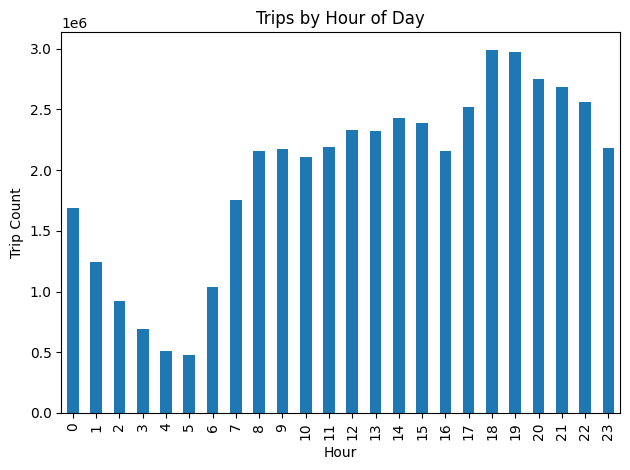

In [24]:
hourly_trips.plot(x="pickup_hour", y="trip_count", kind="bar", legend=False)
plt.title("Trips by Hour of Day")
plt.xlabel("Hour")
plt.ylabel("Trip Count")
plt.tight_layout()
plt.show()

### Trips by Day of Week

Next, the analysis looks at whether trip activity varies meaningfully across the days of the week.

In [26]:
daily_trips = con.execute("""
SELECT
    DAYNAME(tpep_pickup_datetime) AS day_name,
    EXTRACT(dow FROM tpep_pickup_datetime) AS day_num,
    COUNT(*) AS trip_count
FROM taxi_trips
GROUP BY day_name, day_num
ORDER BY day_num
""").df()

daily_trips

,day_name,day_num,trip_count
0,Sunday,0,6139363
1,Monday,1,5766239
2,Tuesday,2,6162402
3,Wednesday,3,6678452
4,Thursday,4,7398279
5,Friday,5,7598101
6,Saturday,6,7506009


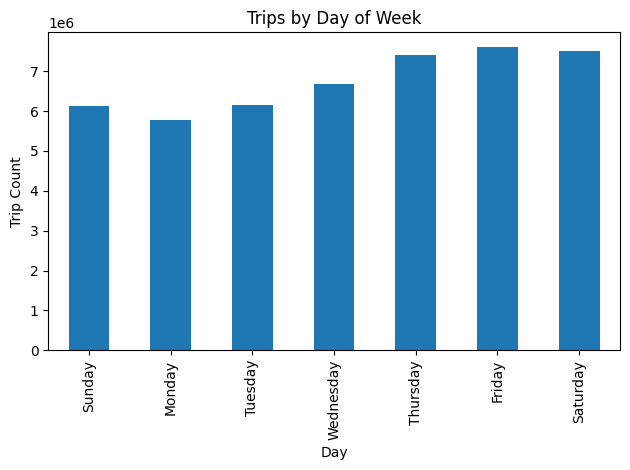

In [27]:
daily_trips.plot(x="day_name", y="trip_count", kind="bar", legend=False)
plt.title("Trips by Day of Week")
plt.xlabel("Day")
plt.ylabel("Trip Count")
plt.tight_layout()
plt.show()

### Trips by Month

This view provides a coarse comparison of overall demand across the available time periods in the dataset.

In [28]:
monthly_trips = con.execute("""
SELECT
    DATE_TRUNC('month', tpep_pickup_datetime) AS month,
    COUNT(*) AS trip_count
FROM taxi_trips
GROUP BY month
ORDER BY month
""").df()

monthly_trips

,month,trip_count
0,2015-01-01,12748986
1,2016-01-01,10906858
2,2016-02-01,11382049
3,2016-03-01,12210952


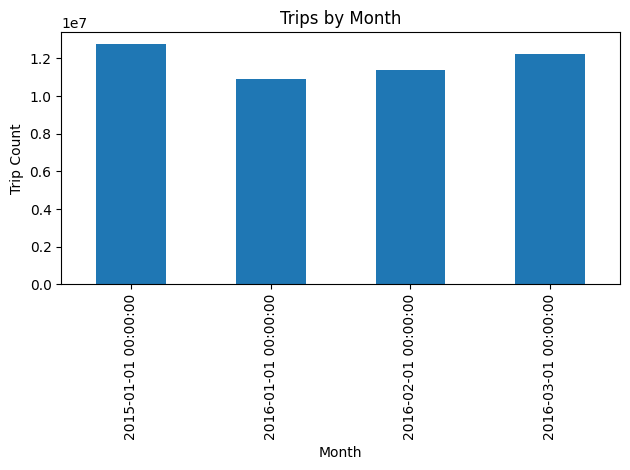

In [29]:
monthly_trips.plot(x="month", y="trip_count", kind="bar", legend=False)
plt.title("Trips by Month")
plt.xlabel("Month")
plt.ylabel("Trip Count")
plt.tight_layout()
plt.show()

## Step 4 - Fare and Distance Analysis

Trip counts are useful, but operational behavior also depends on trip economics.

This section explores:

- average fare by hour
- average distance by passenger count
- total revenue by month

### Average Fare by Hour

This analysis asks whether certain times of day tend to produce higher average trip totals.

In [30]:
fare_by_hour = con.execute("""
SELECT
    EXTRACT(hour FROM tpep_pickup_datetime) AS pickup_hour,
    ROUND(AVG(total_amount), 2) AS avg_total_amount
FROM taxi_trips
GROUP BY pickup_hour
ORDER BY pickup_hour
""").df()

fare_by_hour

,pickup_hour,avg_total_amount
0,0,16.38
1,1,15.91
2,2,15.68
3,3,16.19
4,4,18.32
5,5,19.94
6,6,16.06
7,7,14.60
8,8,14.56
9,9,14.54


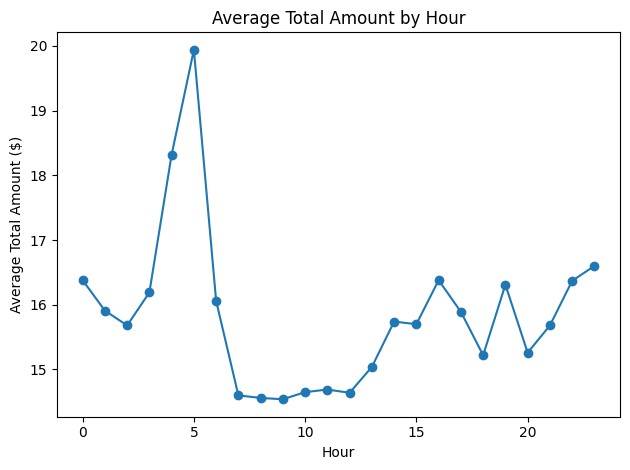

In [31]:
fare_by_hour.plot(x="pickup_hour", y="avg_total_amount", kind="line", marker="o", legend=False)
plt.title("Average Total Amount by Hour")
plt.xlabel("Hour")
plt.ylabel("Average Total Amount ($)")
plt.tight_layout()
plt.show()

### Average Trip Distance by Passenger Count

This query explores whether trips differ materially depending on how many passengers are riding.

In [32]:
distance_by_passenger = con.execute("""
SELECT
    passenger_count,
    COUNT(*) AS trip_count,
    ROUND(AVG(trip_distance), 2) AS avg_trip_distance,
    ROUND(AVG(total_amount), 2) AS avg_total_amount
FROM taxi_trips
GROUP BY passenger_count
ORDER BY passenger_count
""").df()

distance_by_passenger

,passenger_count,trip_count,avg_trip_distance,avg_total_amount
0,0,8214,2.13,16.69
1,1,33537914,7.65,15.48
2,2,6719430,9.36,16.16
3,3,1912291,9.16,15.78
4,4,911351,5.99,15.79
5,5,2551660,2.95,15.59
6,6,1607758,2.88,15.30
7,7,81,3.55,44.66
8,8,78,5.23,55.07
9,9,68,4.74,48.55


### Revenue by Month

This query aggregates total revenue across the available months in the dataset.

In [33]:
monthly_revenue = con.execute("""
SELECT
    DATE_TRUNC('month', tpep_pickup_datetime) AS month,
    ROUND(SUM(total_amount), 2) AS total_revenue
FROM taxi_trips
GROUP BY month
ORDER BY month
""").df()

monthly_revenue

,month,total_revenue
0,2015-01-01,1.926154e+08
1,2016-01-01,1.705985e+08
2,2016-02-01,1.775900e+08
3,2016-03-01,1.959347e+08


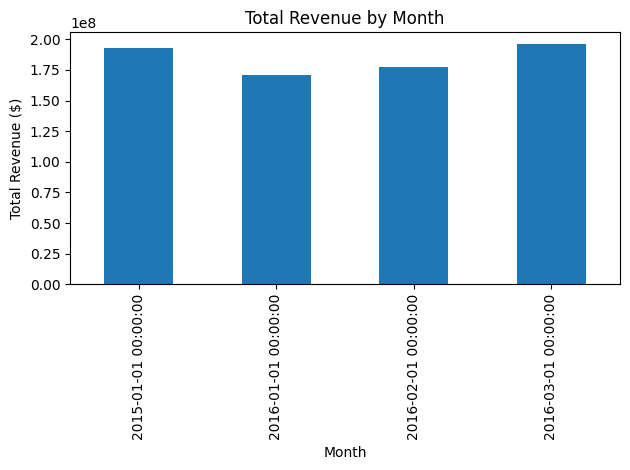

In [34]:
monthly_revenue.plot(x="month", y="total_revenue", kind="bar", legend=False)
plt.title("Total Revenue by Month")
plt.xlabel("Month")
plt.ylabel("Total Revenue ($)")
plt.tight_layout()
plt.show()

## Step 5 - Analytical SQL Patterns

This section focuses on patterns that frequently appear in real analytics work, including:

- ranking
- cumulative totals
- grouped comparisons
- window functions

### Ranking Passenger Groups by Trip Volume

This query ranks passenger-count groups by the number of trips recorded in the cleaned dataset.

In [35]:
ranked_passenger_groups = con.execute("""
SELECT
    passenger_count,
    COUNT(*) AS trip_count,
    RANK() OVER (ORDER BY COUNT(*) DESC) AS trip_rank
FROM taxi_trips
GROUP BY passenger_count
ORDER BY trip_rank
""").df()

ranked_passenger_groups

,passenger_count,trip_count,trip_rank
0,1,33537914,1
1,2,6719430,2
2,5,2551660,3
3,3,1912291,4
4,6,1607758,5
5,4,911351,6
6,0,8214,7
7,7,81,8
8,8,78,9
9,9,68,10


### Cumulative Trips by Hour

This query demonstrates a cumulative metric using a window function.

It shows how trip volume accumulates across the day.

In [36]:
cumulative_hourly = con.execute("""
WITH hourly AS (
    SELECT
        EXTRACT(hour FROM tpep_pickup_datetime) AS pickup_hour,
        COUNT(*) AS trip_count
    FROM taxi_trips
    GROUP BY pickup_hour
)
SELECT
    pickup_hour,
    trip_count,
    SUM(trip_count) OVER (ORDER BY pickup_hour) AS cumulative_trips
FROM hourly
ORDER BY pickup_hour
""").df()

cumulative_hourly

,pickup_hour,trip_count,cumulative_trips
0,0,1691459,1691459.0
1,1,1246344,2937803.0
2,2,918449,3856252.0
3,3,689141,4545393.0
4,4,513887,5059280.0
5,5,477293,5536573.0
6,6,1034368,6570941.0
7,7,1756976,8327917.0
8,8,2154883,10482800.0
9,9,2173883,12656683.0


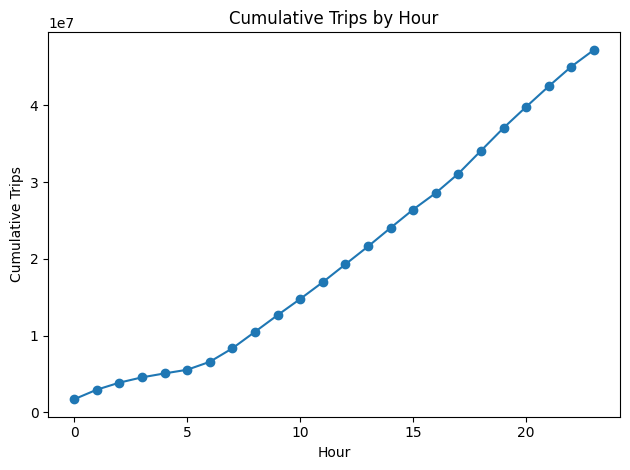

In [37]:
cumulative_hourly.plot(x="pickup_hour", y="cumulative_trips", kind="line", marker="o", legend=False)
plt.title("Cumulative Trips by Hour")
plt.xlabel("Hour")
plt.ylabel("Cumulative Trips")
plt.tight_layout()
plt.show()

## Step 6 - Key Findings

At this stage, the notebook transitions from query execution to analytical interpretation.

The goal is not only to generate results, but to identify meaningful patterns in demand, fares, and passenger behavior.

### Observations

- **Early Morning Demand Spike (~5 AM):**  
  Trip volume increases sharply around 5 AM, suggesting the start of the morning commute cycle. This likely reflects workers traveling to offices, transit hubs, and service jobs that begin early in the day.

- **Commuting Patterns Drive Daily Demand:**  
  Taxi usage increases during typical commuting windows and tapers during late-night hours. This indicates that taxi demand is strongly tied to predictable daily work schedules and urban mobility patterns.

- **Weekend Demand Surge (Friday & Saturday):**  
  Trip volume rises significantly on Fridays and Saturdays compared to other weekdays. This pattern likely reflects nightlife, tourism, and social travel rather than work-related commuting.

- **Clear Cyclical Demand Structure:**  
  The dataset shows strong cyclical behavior across both **hourly (daily)** and **weekly** time scales. These consistent patterns suggest the data could support forecasting models for predicting future taxi demand.

- **Large-Scale Data Enables Behavioral Insights:**  
  With millions of trip records, even simple aggregations reveal meaningful patterns about city-scale transportation behavior.

### Potential Applications

These patterns suggest several practical use cases:

- Taxi demand forecasting
- Driver fleet positioning optimization
- Surge pricing strategy
- Urban transportation planning insights

## Conclusion

This notebook extended the Week 1 DuckDB workflow into a more analytical SQL-focused exploration.

Using DuckDB and the NYC Taxi dataset, the analysis demonstrated how large real-world data can be explored locally through:

- grouped aggregations
- time-series analysis
- ranking queries
- cumulative metrics
- visual summaries

This reinforces the idea that modern local analytics tools can support both data exploration and structured analytical workflows without requiring heavy external infrastructure.

In [39]:
con.execute("""
SELECT
    EXTRACT(hour FROM tpep_pickup_datetime) AS hour,
    AVG(total_amount) AS avg_fare,
    SUM(total_amount) AS total_revenue,
    COUNT(*) AS trip_count
FROM taxi_trips
GROUP BY hour
ORDER BY hour
""").df()

,hour,avg_fare,total_revenue,trip_count
0,0,16.384362,2.771348e+07,1691459
1,1,15.905918,1.982425e+07,1246344
2,2,15.676618,1.439817e+07,918449
3,3,16.186311,1.115465e+07,689141
4,4,18.321434,9.415147e+06,513887
5,5,19.939443,9.516957e+06,477293
6,6,16.061785,1.661380e+07,1034368
7,7,14.598046,2.564842e+07,1756976
8,8,14.562442,3.138036e+07,2154883
9,9,14.539669,3.160754e+07,2173883


In [40]:
con.execute("""
SELECT
    passenger_count,
    COUNT(*) AS trips
FROM taxi_trips
GROUP BY passenger_count
ORDER BY passenger_count
""").df()

,passenger_count,trips
0,0,8214
1,1,33537914
2,2,6719430
3,3,1912291
4,4,911351
5,5,2551660
6,6,1607758
7,7,81
8,8,78
9,9,68


In [42]:
con.execute("""
SELECT
    ROUND(trip_distance,1) AS distance,
    COUNT(*) AS trips
FROM taxi_trips
GROUP BY distance
ORDER BY trips DESC
LIMIT 20
""").df()

,distance,trips
0,0.9,2084142
1,1.0,2066844
2,0.8,2051065
3,1.1,1981494
4,0.7,1923510
5,1.2,1884813
6,1.3,1775173
7,0.6,1667610
8,1.4,1666134
9,1.5,1561129
